In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

large_data_dir = gf_utils.large_data_dir

In [ ]:
gf_dir = large_data_dir + 'gf_CL3_0bp_genotype_GF/BC3_giftwrap/'
adata_path = large_data_dir + 'CL3_0bp_genotype_GF.h5ad'


In [3]:
### filter and label manifest 
manifest = gf_utils.get_manifest(gf_dir)

manifest['name'] = manifest['name'].str.replace('_1','').str.replace('_0','')
manifest['type'] = '0bp_genotyping'
manifest.loc[manifest['name'].str.contains('0bp'),'type'] = 'control'
manifest.loc[manifest['name'].str.contains('alt'),'type'] = 'alt' ## these shouldn't be here (incorrect barcode upstream of probe)
manifest.loc[manifest['name'].str.contains('LHS'),'type'] = 'lhs_probe' ## these shouldn't be here (LHS variant panel)

manifest = manifest.loc[manifest['type'].isin(['0bp_genotyping','control'])].copy() ### only keep 0bp_genotyping probes and controls

## annotate if variant is on lhs or rhs (should all be lhs)
for probe_side, col in [('lhs_probe', 'rhs'), ('rhs_probe', 'lhs')]:
    counts = manifest.groupby(probe_side).size()
    with_two = counts[counts == 2].index ### if variant is on this side, then counts should be 1
    manifest.loc[manifest[probe_side].isin(with_two), 'variant'] = col


manifest['name'] = manifest['name'].str.replace('_LHS','').str.replace('_RHS','').str.replace('_both','')

manifest.loc[manifest['name'] == 'BCR-ABL c.fusion','name'] = 'BCR-ABL'

manifest.index = manifest['index']
manifest = manifest.sort_index()



12555096 UMIs found
Filtering probe reads based on read threshold (0) and min percent supporting (0.9), 12552008 UMIs remaining (99.98%)
Filtering cells based on min counts (0) and genes (0) in WTA
Filtering probe reads based on cell barcodes in adata, 9818579 UMIs remaining (78.20%)
8438299  UMIs remaining after filtering for read threshold: 3


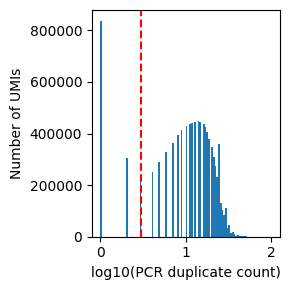

In [4]:
read_threshold = 3
probe_reads = gf_utils.get_input_probe_reads(gf_dir, read_threshold=0, min_percent_supporting=0.9, adata_path=adata_path)
gf_utils.plot_reads_per_umi(probe_reads=probe_reads, read_threshold=read_threshold)

probe_reads = probe_reads.loc[probe_reads['pcr_duplicate_count'] > read_threshold]

print(len(probe_reads), ' UMIs remaining after filtering for read threshold:', read_threshold)
## add probe metadata to probe_reads
probe_reads = probe_reads.merge(manifest[['gap_probe_sequence','gapfill_from_transcriptome','name','type','gapfill_start','variant']], left_on='probe_idx',right_index=True, how='left')


In [5]:
adata = gf_utils.read_adata(adata_path)
probe_barcode = probe_reads.iloc[0]['barcode'].split('-')[0][16:]
adata.obs['probe_barcode'] = adata.obs.index.str.split('-').str[0].str[16:]
adata = adata[adata.obs['probe_barcode'] == probe_barcode].copy() ### filter to only this probe barcode

In [7]:
predicted_genotypes = pd.read_csv('../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv',sep=',')
predicted_genotypes.loc[predicted_genotypes['name'] == 'KRAS c.35G>*','name'] = 'KRAS c.34G>T'
predicted_genotypes = predicted_genotypes.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
predicted_genotypes = predicted_genotypes.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})

predicted_genotypes.loc['BCR-ABL','K562'] = 'mutated' ### fix here because we will not consider ref probe so BCR-ABL might as well be homozygous mutated

predicted_genotypes = predicted_genotypes.dropna()
probe_reads = probe_reads.merge(predicted_genotypes.reset_index().melt(id_vars='name', var_name='cell_type', value_name='genotype'), on = ['name','cell_type'], how='left')


In [8]:
### add allele calls to probe_reads

probe_reads['allele_call'] = np.select(
    [
        probe_reads['type'] == 'gapfill',
        probe_reads['type'] == '0bp_genotyping'
    ],
    [
        np.where(
            probe_reads['gapfill'] == probe_reads['gapfill_from_transcriptome'], 'ref',
            np.where(probe_reads['gapfill'] == probe_reads['gap_probe_sequence'], 'alt', None)
        ),
        np.where(
            probe_reads['gapfill_start'].notna(), 'ref', 'alt' ### for dual probes assign ref if gapfill_start is not null (then probes were found in wt transcriptome)
        )
    ],
    default=None
)


In [9]:
# Calculate the proportion of 'ref' allele calls among wt genotypes for each probe (name)
wt_allele_calls = probe_reads.loc[
    (probe_reads['type'] == '0bp_genotyping') &
    (probe_reads['genotype'] == 'wt') &
    (probe_reads['allele_call'].isin(['ref', 'alt']))
]

p_ref_given_wt = wt_allele_calls.groupby('name')['allele_call'].apply(lambda x: (x == 'ref').mean())


# Calculate the proportion of 'alt' allele calls among mutated genotypes for each probe (name)
mutated_allele_calls = probe_reads.loc[
    (probe_reads['type'] == '0bp_genotyping') &
    (probe_reads['genotype'] == 'mutated') &
    (probe_reads['allele_call'].isin(['ref', 'alt']))
]

p_alt_given_mutated = mutated_allele_calls.groupby('name')['allele_call'].apply(lambda x: (x == 'alt').mean())

p_ref_given_wt.median(), p_alt_given_mutated.median()

(0.9687814702920443, 0.9300242650950552)

In [10]:
probe_counts = probe_reads.loc[
    (probe_reads['type'] == '0bp_genotyping') &
    (probe_reads['genotype'].isin(['wt','mutated'])) &
    (probe_reads['allele_call'].isin(['ref', 'alt']))
][['name','genotype','allele_call']].value_counts().reset_index()

probe_counts['correct'] = np.where(
    (probe_counts['genotype'] == 'wt') & (probe_counts['allele_call'] == 'ref'), True, 
    np.where(
        (probe_counts['genotype'] == 'mutated') & (probe_counts['allele_call'] == 'alt'), True,
        False
    )
)

probe_counts.to_csv('../output/dual_probe_rhs_probe_counts.csv')


In [11]:
### define likelihoods for gapfill and dual probes to use for cell genotype calls

p_wt_given_wt_gapfill = 0.99
p_wt_given_wt_dual = 0.9

probe_reads['p_gapfill_given_ref'] = np.select(
    [
        probe_reads['type'] == 'gapfill',
        probe_reads['type'] == '0bp_genotyping'
    ],
    [
        probe_reads['allele_call'].map({'ref': p_wt_given_wt_gapfill, 'alt': 1 - p_wt_given_wt_gapfill}),
        probe_reads['allele_call'].map({'ref': p_wt_given_wt_dual, 'alt': 1 - p_wt_given_wt_dual})
    ],
    default=np.nan
)

probe_reads['p_gapfill_given_alt'] = np.select(
    [
        probe_reads['type'] == 'gapfill',
        probe_reads['type'] == '0bp_genotyping'
    ],
    [
        probe_reads['allele_call'].map({'ref': 1 - p_wt_given_wt_gapfill, 'alt': p_wt_given_wt_gapfill}),
        probe_reads['allele_call'].map({'ref': 1 - p_wt_given_wt_dual, 'alt': p_wt_given_wt_dual})
    ],
    default=np.nan
)
probe_reads['pcr_swap_likelihood'] = 0 ### we filtered UMIs with low pcr duplicate counts so we are not using this likelihood in the model
probe_reads.reset_index(inplace=True, drop=True)

variants = predicted_genotypes.index.tolist() ### include all variants for which we have a bulk genotype
targets = manifest.loc[manifest['type'] == '0bp_genotyping','name'].unique().tolist() ### all targets even if no bulk genotype or no counts

### add genotypes to adata
adata = gf_utils.get_genotyped_adata(probe_reads.loc[probe_reads['type'] == '0bp_genotyping'].drop('probe_idx',axis=1).rename(columns={'name':'probe_idx'}), adata, variants)

In [12]:
adata.obsm['predicted_genotypes'] = pd.DataFrame(adata.obs['cell_type']).merge(predicted_genotypes.transpose(), left_on='cell_type', right_index=True, how='left').drop('cell_type', axis=1)


In [13]:
## save summary stats

prop_genotyped = adata.obsm['genotypes'].notna().mean()
mean_counts = probe_reads.loc[(probe_reads['type'] == '0bp_genotyping') & (probe_reads['allele_call'].notna())]['name'].value_counts() / len(adata.obs_names)
summary = pd.DataFrame([p_alt_given_mutated, p_ref_given_wt, prop_genotyped, mean_counts], index = ['p_alt_given_mutated','p_ref_given_wt','prop_genotyped','mean_counts']).transpose()
summary = summary.reindex(targets) ### make sure to include all variants even if they have no counts
summary['prop_genotyped'] = summary['prop_genotyped'].fillna(0)
summary['mean_counts'] = summary['mean_counts'].fillna(0)
summary.to_csv('../output/dual_probe_rhs_summary.csv')
